# Hotel revenue Forecasting Pipeline 

This notebook demonstrates the complete pipeline for forecasting hotel revenue values using various time series models, targeting multiple forecast horizons

# Forecasting pipeline

1.  **Exploratory analysis**:
    1.  Univariate statistical analysis (applied to averages or specific examples)
    2.  Descriptive statistics for multivariate TS
    3.  Correlation between TS
    4.  etc..
2.  **Univariate benchmark models**. Chose one or more benchmark methods we have seen in the course and retrieve a baseline in terms of performance
    1.  naive methods
    2.  Holt-Winters, AR(I)MAX
3.  **Model proposal and training**
    1.  cross validation (time or purged k-fold) and hyperpar optimization (potentially per target or averaged)
    2.  point and *probabilistic* forecasts
    3.  choice of the score metrics
4.  **Model selection**
    1.  Selection (potentially per target or overall best)
    2.  Reporting results



## 1. Data Loading and Initial Exploration

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from datetime import datetime, timedelta

# Time series libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Scikit-learn for additional models
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Set style and suppress warnings
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
# Load the dataset
with open('hotels.pk', 'rb') as f:
    data = pickle.load(f)

# Convert to DataFrame if needed
if not isinstance(data, pd.DataFrame):
    df = pd.DataFrame(data)
else:
    df = data.copy()

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully!
Dataset shape: (23254, 4)

Column names:
['Location', 'Revenue', 'Demand', 'Occupancy']


In [3]:
print(df.index.dtype)

datetime64[ns]


In [4]:
df.head()

,Location,Revenue,Demand,Occupancy
Date,,,,
2013-01-01,NewYork,2.442363e+06,13063.675000,81.991307
2013-01-02,NewYork,2.018559e+06,13069.608539,82.028548
2013-01-03,NewYork,1.927676e+06,13069.608539,82.028548
2013-01-04,NewYork,1.781664e+06,12653.271887,79.415502
2013-01-05,NewYork,1.824994e+06,12827.322364,80.507892


In [5]:
# Examine the data structure and basic info
print("Data Info:")
print(df.info())
print("\n" + "="*50)
print("Index (Date) Info:")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Number of days: {len(df.index.unique())}")
print("\n" + "="*50)
print("Unique locations:")
locations = df['Location'].unique()
print(locations)
print(f"Number of locations: {len(locations)}")
print("\n" + "="*50)
print("Data per location:")
print(df['Location'].value_counts().sort_values(ascending=False))

Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 23254 entries, 2013-01-01 to 2020-10-31
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Location   23254 non-null  object 
 1   Revenue    23254 non-null  float64
 2   Demand     23254 non-null  float64
 3   Occupancy  23254 non-null  float64
dtypes: float64(3), object(1)
memory usage: 908.4+ KB
None

Index (Date) Info:
Date range: 2012-01-01 00:00:00 to 2020-10-31 00:00:00
Number of days: 3227

Unique locations:
['NewYork' 'Orlando' 'Chicago' 'LosAngeles' 'Washington' 'Atlanta'
 'Dallas' 'Boston']
Number of locations: 8

Data per location:
Location
Atlanta       3227
NewYork       2861
Orlando       2861
Chicago       2861
LosAngeles    2861
Washington    2861
Dallas        2861
Boston        2861
Name: count, dtype: int64


## 2. Data Preprocessing


In [6]:
# Basic statistics for each location
print("Revenue Statistics by Location:")
print("="*80)
revenue_stats = df.groupby('Location')['Revenue'].agg(['count', 'mean', 'std', 'min', 'max'])
revenue_stats['mean'] = revenue_stats['mean'].round(0)
revenue_stats['std'] = revenue_stats['std'].round(0)
print(revenue_stats)

print("\n\nMissing values check:")
print(df.isnull().sum())

print("\n\nData types:")
print(df.dtypes)

Revenue Statistics by Location:
            count       mean        std            min           max
Location                                                            
Atlanta      3227  1168859.0   407251.0  300130.994748  3.527372e+06
Boston       2861   815105.0   376528.0  114523.553351  2.035877e+06
Chicago      2861  1275021.0   532755.0  191560.618017  3.194662e+06
Dallas       2861   953418.0   313810.0  246828.548026  2.042266e+06
LosAngeles   2861  1047586.0   307256.0  164409.176800  1.839768e+06
NewYork      2861  3152937.0  1208497.0  588695.817812  7.940696e+06
Orlando      2861  1860535.0   691470.0   88994.827420  4.346277e+06
Washington   2861  1527573.0   597672.0  275723.044727  3.974323e+06


Missing values check:
Location     0
Revenue      0
Demand       0
Occupancy    0
dtype: int64


Data types:
Location      object
Revenue      float64
Demand       float64
Occupancy    float64
dtype: object


## 3. Exploratory Data Analysis and Visualization

provare a visualizzare con ipywidget (grafici potrebbero essere migliori)
stessa cosa nella matrice delle correlazioni, correlazione tra features molto forte -> esplorare correlazione solo tra features per evitare collinearitâ (si potrebbe combinare le features o tenerne solo una delle due)

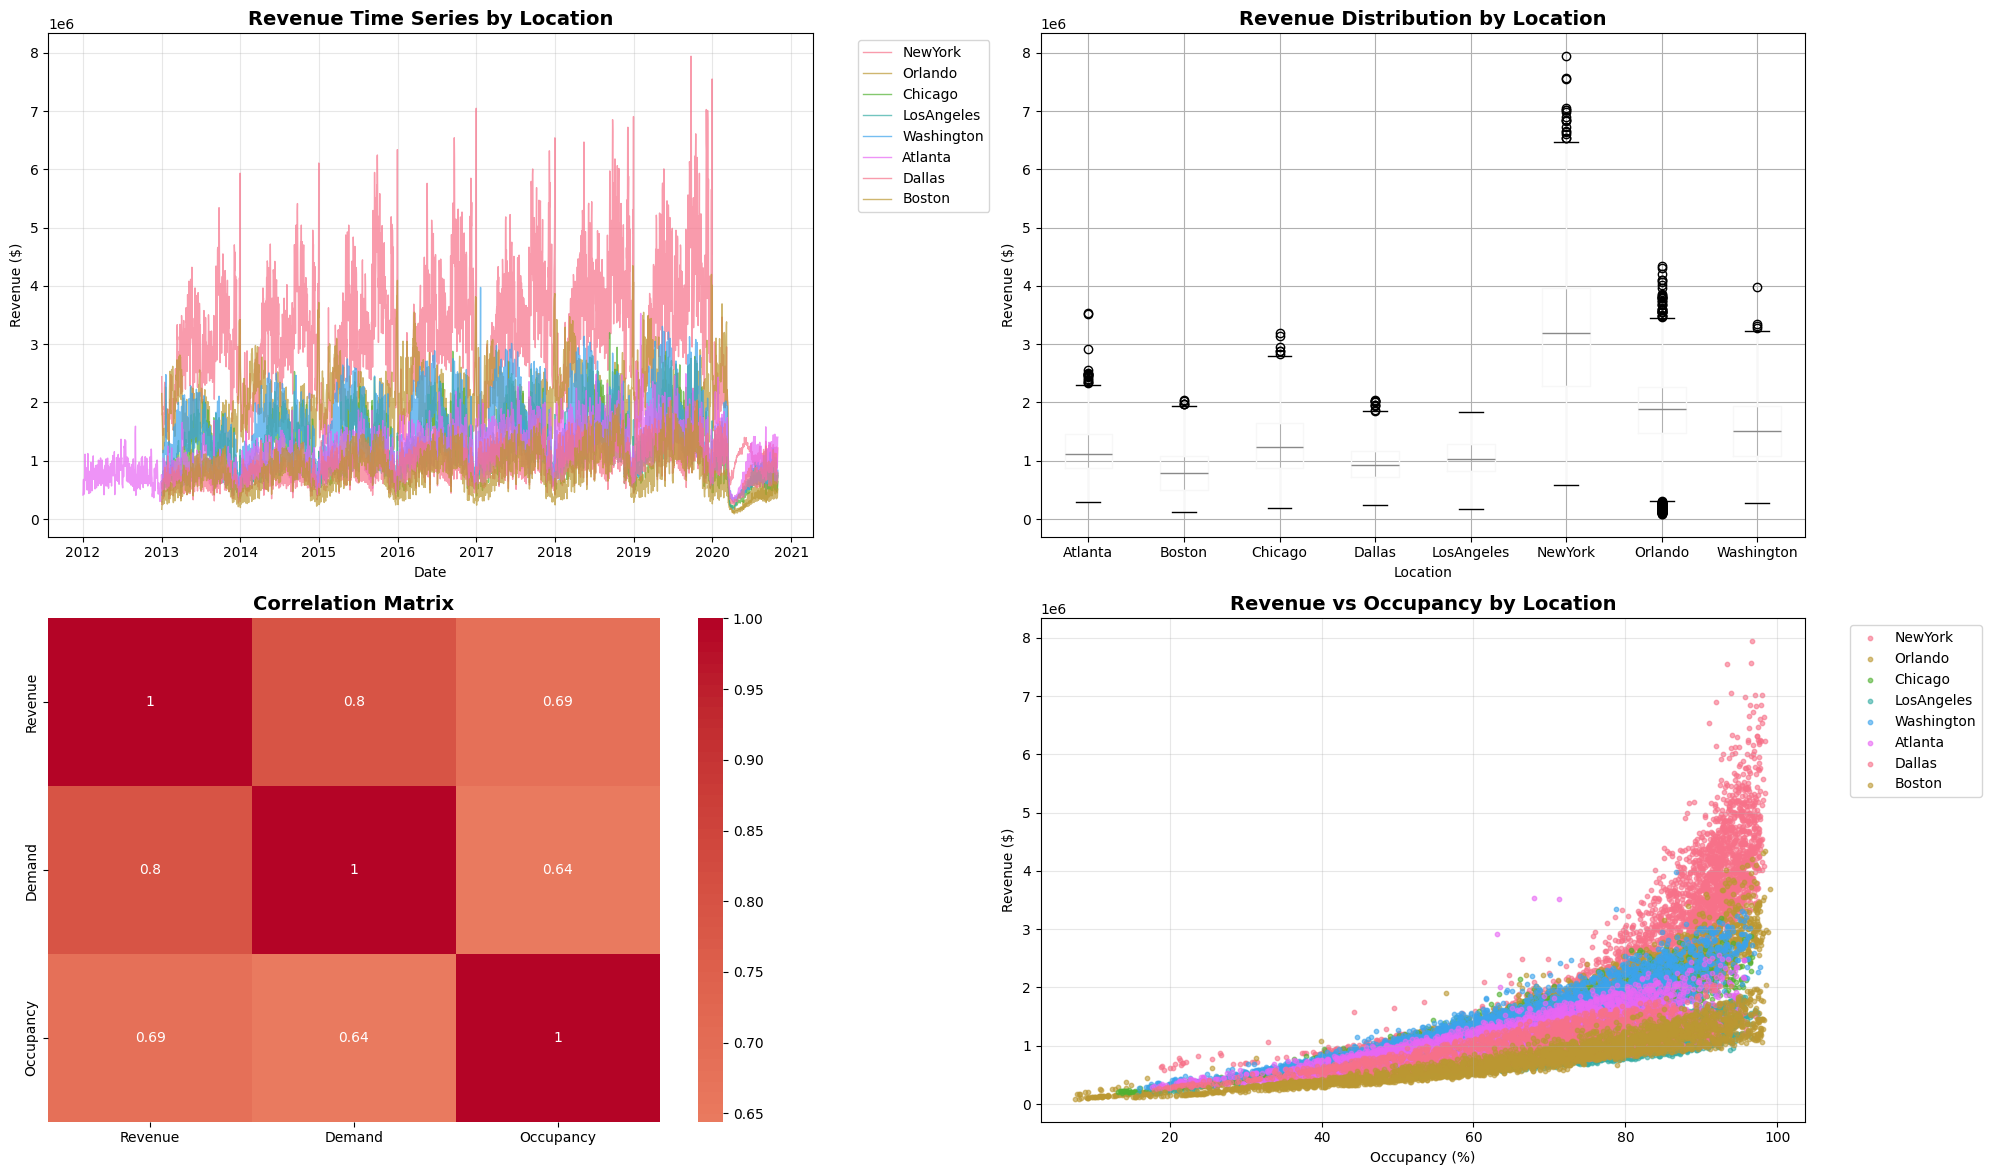

In [7]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# 1. Revenue time series by location
ax1 = axes[0, 0]
for location in df['Location'].unique():
    location_data = df[df['Location'] == location]
    ax1.plot(location_data.index, location_data['Revenue'], 
             label=location, alpha=0.7, linewidth=1)
ax1.set_title('Revenue Time Series by Location', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Revenue ($)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Average revenue by location (box plot)
ax2 = axes[0, 1]
df.boxplot(column='Revenue', by='Location', ax=ax2)
ax2.set_title('Revenue Distribution by Location', fontsize=14, fontweight='bold')
ax2.set_xlabel('Location')
ax2.set_ylabel('Revenue ($)')
plt.suptitle('')  # Remove automatic title

# 3. Correlation matrix
ax3 = axes[1, 0]
# Select numeric columns for correlation
numeric_cols = ['Revenue', 'Demand', 'Occupancy']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax3)
ax3.set_title('Correlation Matrix', fontsize=14, fontweight='bold')

# 4. Revenue vs Occupancy scatter plot
ax4 = axes[1, 1]
for location in df['Location'].unique():
    location_data = df[df['Location'] == location]
    ax4.scatter(location_data['Occupancy'], location_data['Revenue'], 
                label=location, alpha=0.6, s=10)
ax4.set_title('Revenue vs Occupancy by Location', fontsize=14, fontweight='bold')
ax4.set_xlabel('Occupancy (%)')
ax4.set_ylabel('Revenue ($)')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

we can see an important correlation between Demand, Occupancy and our target Revenue. We want to check if there is collinearity between features to avoid overfitting in the model

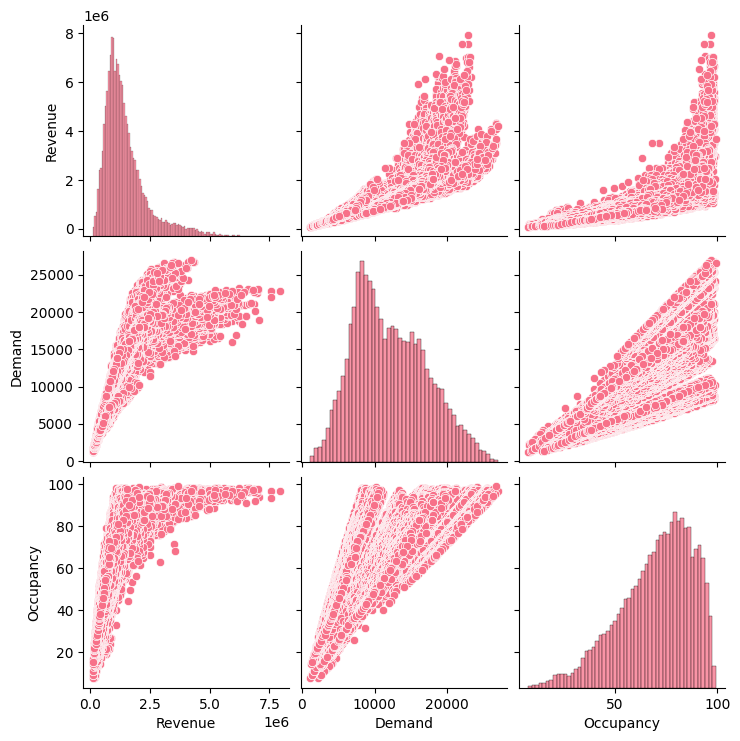

In [8]:
sns.pairplot(df[['Revenue', 'Demand', 'Occupancy']])
plt.show()

There is heavy correlation between features, we should consider removing some of them to avoid collinearity issues in the model training phase.

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Esempio: solo alcune feature
X = df[['Revenue', 'Demand', 'Occupancy']].dropna()

# Aggiungi una costante per il calcolo del VIF
from statsmodels.tools.tools import add_constant
X_const = add_constant(X)

vif = pd.DataFrame()
vif["feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vif #vif is 


,feature,VIF
0,const,20.075335
1,Revenue,3.173136
2,Demand,2.865540
3,Occupancy,1.990786


| feature    | VIF        | Action                                                   |
|------------|------------|----------------------------------------------------------|
| const      | 20.075335  | indicates high multicollinearity so we can ignore it    |
| Revenue    | 3.173136   | moderate multicollinearity so we can keep it            |
| Demand     | 2.865540   | moderate multicollinearity so we can keep it            |
| Occupancy  | 1.990786   | low multicollinearity so we can keep it                 |


### Handling COVID
Because there is an external event that breaks the equilibrium condition, we decided to discard the COVID period, oterwise we can try to model it like a change of state (pre and post covid)

In [10]:
df = df.sort_index()
df = df.loc[:'2019-12-31']

## 4. City Selection and Focus

Based on the analysis, let's select **Boston** as our focus city for forecasting due to:
1. Highest revenue levels among all cities
2. Strong seasonal patterns visible in the time series
3. Good data quality and range

In [11]:
# Filter for one city
CITY = "Boston"
df_boston = df[df['Location'] == CITY].copy()

# Use index (already DateTimeIndex)
df_boston.index = pd.to_datetime(df_boston.index)

# Restrict date range
df_boston
df_boston.head()


,Location,Revenue,Demand,Occupancy
Date,,,,
2013-01-01,Boston,166542.843005,1896.791481,22.856617
2013-01-02,Boston,245252.313124,2744.958462,33.077154
2013-01-03,Boston,289687.425946,3172.063926,38.223838
2013-01-04,Boston,297390.047491,3308.052694,39.862523
2013-01-05,Boston,291848.455941,3235.525351,38.988557


In [12]:
print(df_boston.index.min(), "→", df_boston.index.max())

#verify that the intervals are regualr (daily) 

print(df_boston.index.to_series().diff().value_counts())

2013-01-01 00:00:00 → 2019-12-31 00:00:00
Date
1 days    2555
Name: count, dtype: int64


The dataset contains 2555 days of data for Boston, which is sufficient for training robust forecasting models and as we can see they span ranges that avoid covid period.

In [13]:
from ipywidgets import interact, interactive, IntSlider, DatePicker

start_picker = DatePicker(
    description='Start date',
    value=df.index.min().date(),
    disabled=False
)
end_picker = DatePicker(
    description='End date',
    value=df.index.max().date(),
    disabled=False
)

@interact(start=start_picker, end=end_picker)
def plot_time_series(start, end):
    mask = (df_boston.index >= pd.to_datetime(start)) & (df_boston.index <= pd.to_datetime(end))
    plt.figure(figsize=(10, 4))
    plt.plot(df_boston.loc[mask].index, df_boston.loc[mask]['Revenue'], color='teal')
    plt.title(f"Hotel Revenue ({start} → {end})")
    plt.xlabel("Date")
    plt.ylabel("Revenue")
    plt.grid(True, alpha=0.3)
    plt.show()


interactive(children=(DatePicker(value=datetime.date(2012, 1, 1), description='Start date', step=1), DatePicke…

because the line plot is a bit chaotic, let's analyse the timeserie in  a macro view

In [14]:
@interact(start=start_picker, end=end_picker)
def plot_rolling(start, end):
    mask = (df_boston.index >= pd.to_datetime(start)) & (df_boston.index <= pd.to_datetime(end))
    subset = df_boston.loc[mask]

    plt.figure(figsize=(12,6))
    plt.plot(subset['Revenue'].rolling(7, center=True).mean(), 
             label='Rolling 7-day', alpha=0.8, color='teal')
    plt.plot(subset['Revenue'].rolling(30, center=True).mean(), 
             label='Rolling 30-day (≈ monthly)', alpha=0.8, color='orange')
    plt.plot(subset['Revenue'].rolling(365, center=True).mean(), 
             label='Rolling 365-day (yearly)', alpha=0.9, color='crimson')

    plt.title(f'Hotel Revenue – Rolling Averages ({start} → {end})')
    plt.xlabel('Date')
    plt.ylabel('Revenue (smoothed)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(DatePicker(value=datetime.date(2012, 1, 1), description='Start date', step=1), DatePicke…

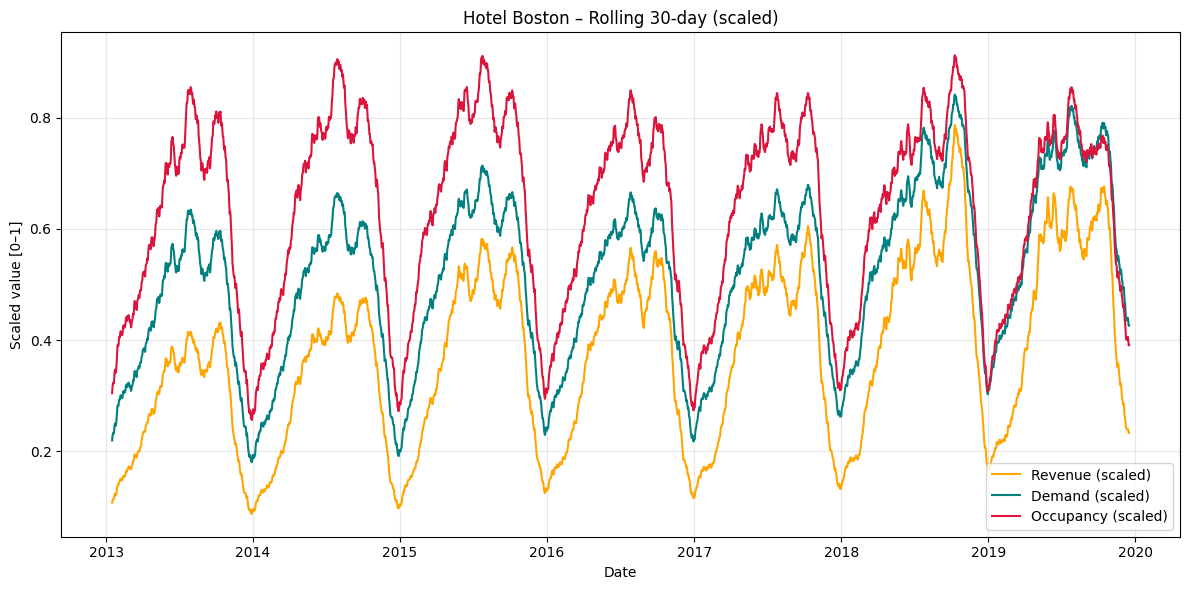

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_boston[['Revenue', 'Demand', 'Occupancy']])
scaled_df = pd.DataFrame(scaled, index=df_boston.index, columns=['Revenue', 'Demand', 'Occupancy'])

plt.figure(figsize=(12,6))
plt.plot(scaled_df['Revenue'].rolling(30, center=True).mean(), label='Revenue (scaled)', color='orange')
plt.plot(scaled_df['Demand'].rolling(30, center=True).mean(), label='Demand (scaled)', color='teal')
plt.plot(scaled_df['Occupancy'].rolling(30, center=True).mean(), label='Occupancy (scaled)', color='crimson')

plt.title('Hotel Boston – Rolling 30-day (scaled)')
plt.xlabel('Date')
plt.ylabel('Scaled value [0–1]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


As we can see from the rolling 30 day shows clear seasonal patterns with peaks during summer and troughs in winter, which is typical for the hotel industry.

In [16]:
@interact(metric=['Revenue', 'Demand', 'Occupancy'])
def plot_seasonal(metric):
    df_boston['Month'] = df_boston.index.month_name().str.slice(stop=3)
    df_boston['Year'] = df_boston.index.year
    monthly = df_boston.groupby(['Year', 'Month'])[metric].mean().reset_index()
    
    # Ordine corretto dei mesi
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    monthly['Month'] = pd.Categorical(monthly['Month'], categories=month_order, ordered=True)
    
    plt.figure(figsize=(12,6))
    sns.lineplot(data=monthly, x='Month', y=metric, hue='Year', palette='coolwarm')
    plt.title(f'Seasonal Plot – Monthly {metric} by Year')
    plt.xlabel('Month')
    plt.ylabel(metric)
    plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='metric', options=('Revenue', 'Demand', 'Occupancy'), value='Revenu…

Usually the revenues are higher in the warmer month

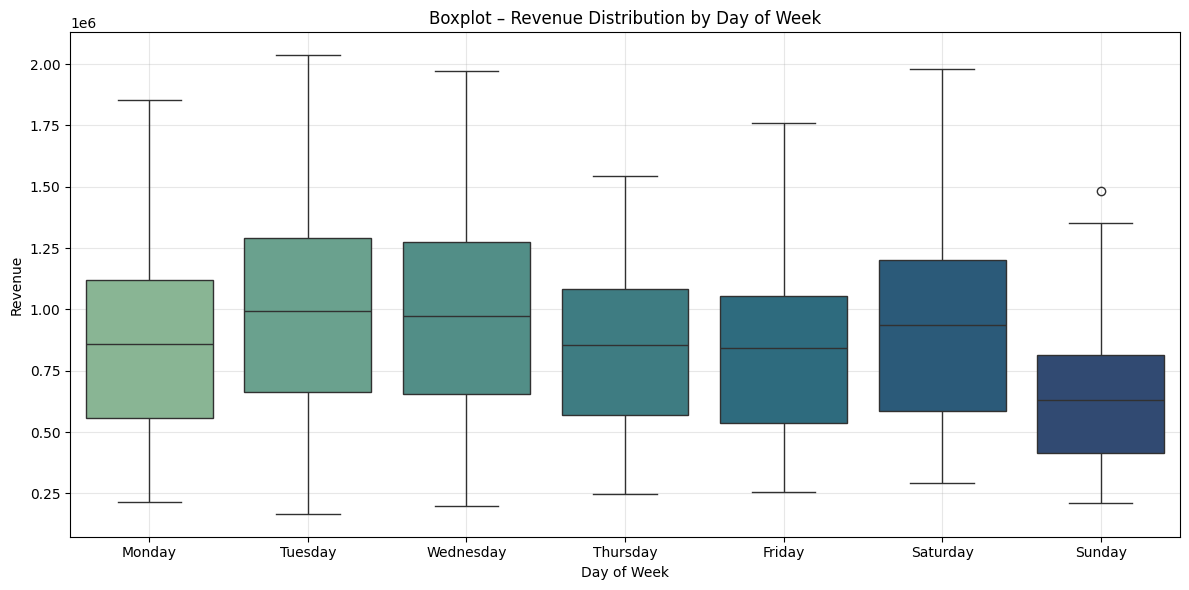

In [17]:
df_boston['DayOfWeek'] = df_boston.index.day_name()
df_boston['DayOfWeek'] = pd.Categorical(df_boston['DayOfWeek'], categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)
plt.figure(figsize=(12,6))
sns.boxplot(data=df_boston, x='DayOfWeek', y='Revenue', palette='crest')
plt.title('Boxplot – Revenue Distribution by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The day of the week shows weekly seasonality with Sunday the day with the lowest revenue

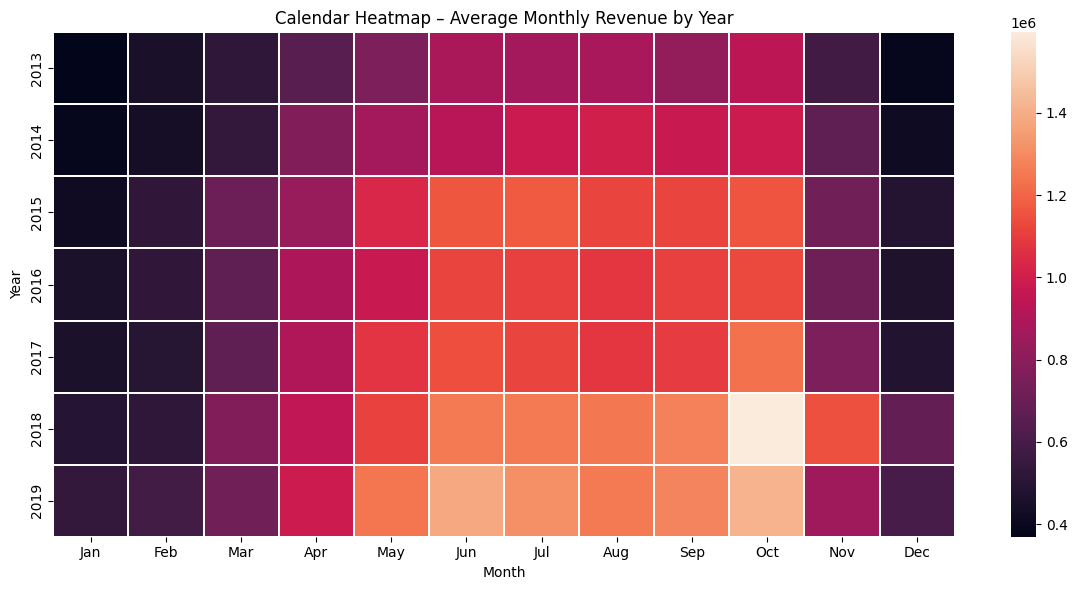

In [18]:
pivot2 = df_boston.pivot_table(values='Revenue',
                               index='Year',
                               columns='Month',
                               aggfunc='mean')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot2 = pivot2[month_order]

plt.figure(figsize=(12,6))
sns.heatmap(pivot2, linewidths=0.3, annot=False)
plt.title('Calendar Heatmap – Average Monthly Revenue by Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

Again we can see the seasonality patterns with higher revenues in summer months and lower in winter ones. with an unusual peak in October 2018 probably due to a special event in the city.

## 4b. Correlation between features for Boston

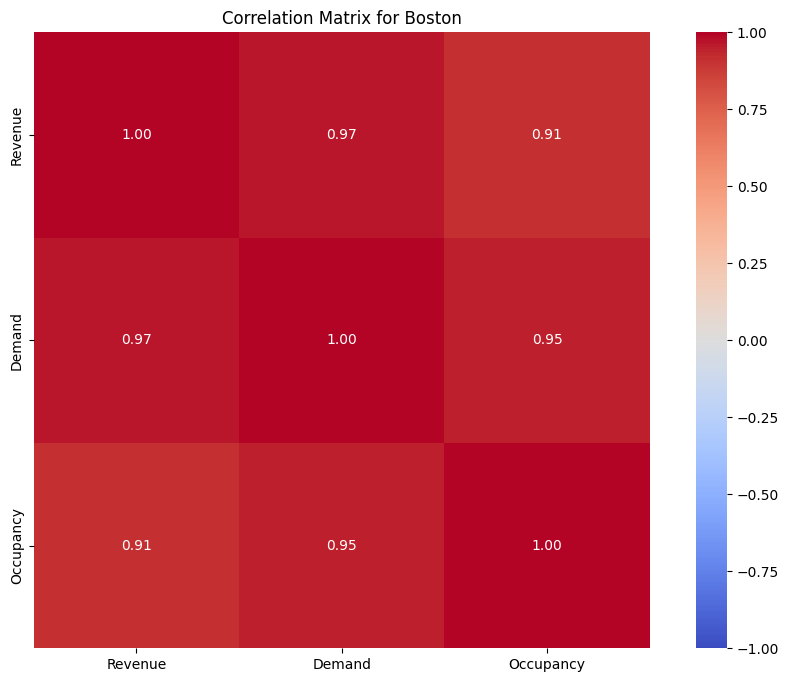

In [19]:
# Correlation Analysis
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_matrix(df, title='Correlation Matrix'):
    plt.figure(figsize=(12, 8))
    sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, vmin=-1, vmax=1)
    plt.title(title)
    plt.show()

plot_correlation_matrix(df_boston[['Revenue', 'Demand', 'Occupancy']], title=f'Correlation Matrix for {CITY}')

Occupancy and Demand show a strong positive correlation with Revenue, indicating that higher occupancy rates and demand levels are associated with increased revenue. This suggests that these variables are important predictors for forecasting revenue in the hotel industry but using them directly may introduce multicollinearity issues in some models as mentioned earlier.
But in our case we will use them as exogenous variables in our models so it should be fine.

Given the strong correlations observed, we could use both either only Demand or only Occupancy as exogenous variables in our forecasting models to predict Revenue. However, using both variables may provide complementary information that could enhance the model's predictive performance.

**Models that can incorporate multiple exogenous variables, such as SARIMAX or LSTM, would be suitable choices for this forecasting task.**

---

## 5. Decomposition

because we don't have missing values and we have high-frequency data (daily) that can exhibit multiple seasonal patterns we can use an extension of STL decomposition for mulitple seasonality known as **MSTL** using LOESS.
To refresh, MSTL decomposes a time series into trend, seasonal, and remainder components, allowing us to analyze each aspect separately. Differently from STL, MSTL can handle multiple seasonal patterns, making it suitable for complex time series data.

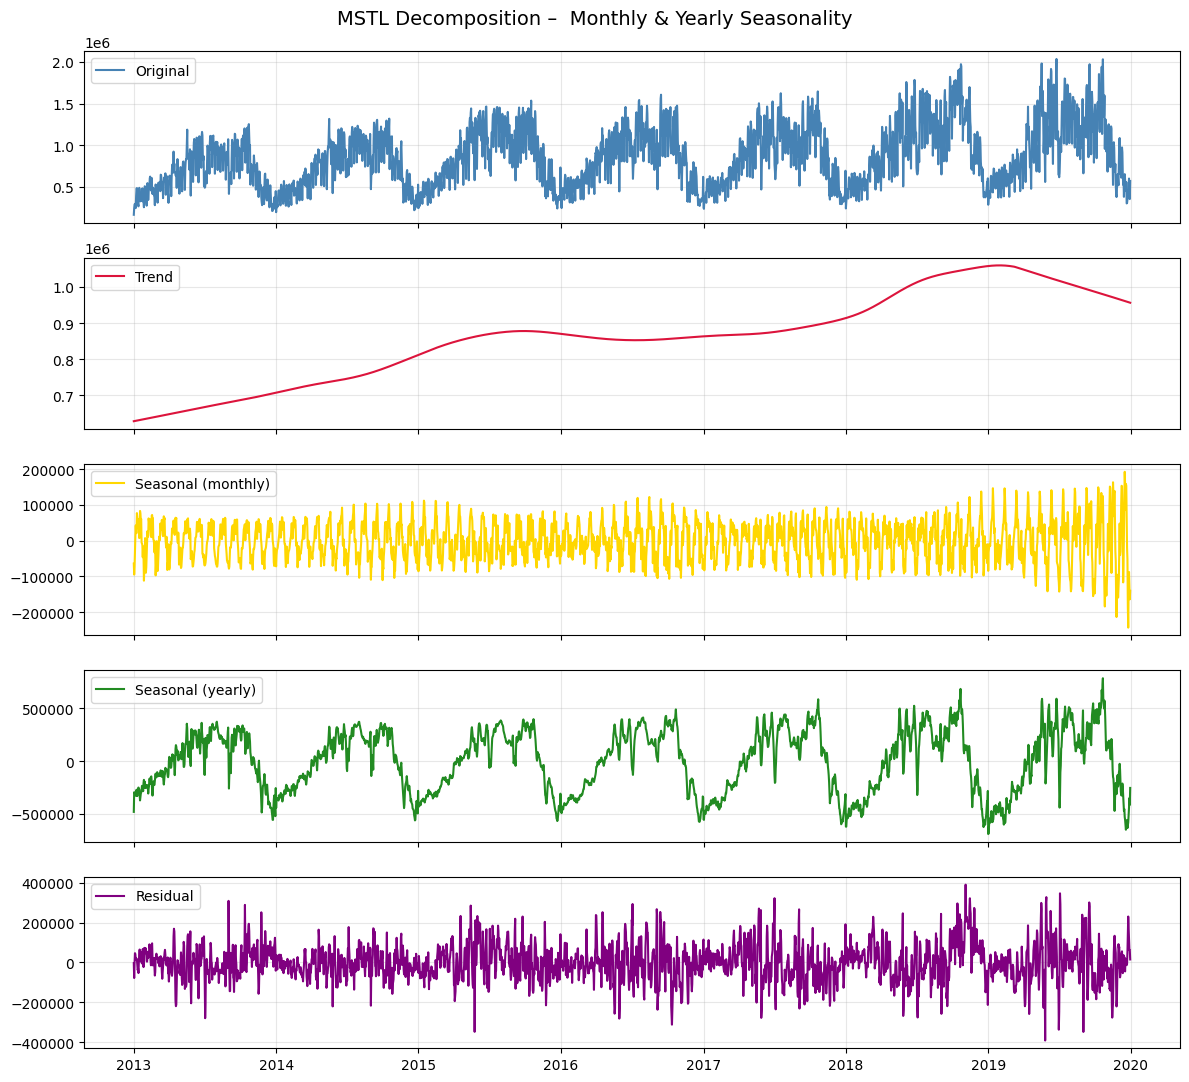

In [20]:
from statsmodels.tsa.seasonal import MSTL
y = df_boston['Revenue'].asfreq('D')
mstl = MSTL(y, periods=(7, 30, 365))
res = mstl.fit()

trend = res.trend
seasonal_month = res.seasonal['seasonal_30']
seasonal_year = res.seasonal['seasonal_365']
resid = res.resid

# Plot
fig, axs = plt.subplots(5, 1, figsize=(12, 11), sharex=True)
axs[0].plot(y, color='steelblue', label='Original')
axs[1].plot(trend, color='crimson', label='Trend')
axs[2].plot(seasonal_month, color='gold', label='Seasonal (monthly)')
axs[3].plot(seasonal_year, color='forestgreen', label='Seasonal (yearly)')
axs[4].plot(resid, color='purple', label='Residual')

for ax in axs:
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('MSTL Decomposition –  Monthly & Yearly Seasonality', fontsize=14)
plt.tight_layout()
plt.show()

## Frequency Domain Analysis (FFT)

In [ ]:
from scipy.fft import fft, fftfreq
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

# Create figure with 3 subplots
fig = make_subplots(rows=3, cols=1, subplot_titles=("Revenue FFT Spectrum", "Demand FFT Spectrum", "Occupancy FFT Spectrum"),
                    vertical_spacing=0.1)

# Function to compute and plot FFT
def plot_fft(data, column, row, color, n_top_periods=10):
    # Get the values and compute FFT
    y = data[column].values
    N = len(y)
    
    # Compute sample spacing (assuming daily data)
    time_diff = pd.Series(data.index).diff().median().total_seconds()
    T = time_diff / (24 * 3600)  # Convert to days
    
    # Compute FFT
    yf = fft(y)
    xf = fftfreq(N, T)[:N//2]
    magnitudes = 2.0/N * np.abs(yf[:N//2])
    
    # Skip the DC component (0 frequency) and filter frequencies above 0.002
    mask = (xf >= 0.002) & (xf > 0)
    xf_filtered = xf[mask]
    magnitudes_filtered = magnitudes[mask]
    
    # Plot only the filtered frequencies
    fig.add_trace(
        go.Scatter(x=xf_filtered, y=magnitudes_filtered, 
                  mode='lines', name=column, line=dict(color=color)),
        row=row, col=1
    )
    
    # Find top n periods based on magnitude
    top_periods = []
    if len(magnitudes_filtered) > 0:
        # Get indices of top n peaks from the filtered data
        peaks = np.argsort(magnitudes_filtered)[-n_top_periods:]  # Get indices of top peaks
        
        for peak_idx in peaks:
            freq = xf_filtered[peak_idx]
            log_x_adj = np.log10(freq)
            magnitude = magnitudes_filtered[peak_idx]
            period = 1/freq
            
            # Add to list of top periods
            top_periods.append({
                'period': period,
                'frequency': freq,
                'magnitude': magnitude
            })
            
            # Add annotation to plot
            fig.add_annotation(
                x=log_x_adj, y=magnitude,
                text=f"{period:.1f} days",
                showarrow=True, arrowhead=1,
                row=row, col=1
            )
            
    # Sort periods by magnitude (highest first)
    top_periods.sort(key=lambda x: x['magnitude'], reverse=False)
    
    return top_periods

# Plot FFT for each column
peaks_revenue = plot_fft(df_boston, 'Revenue', 1, 'blue')
peaks_demand = plot_fft(scaled_df, 'Demand', 2, 'green')
peaks_occupancy = plot_fft(scaled_df, 'Occupancy', 3, 'red')

# Update layout
fig.update_layout(
    title_text=f"FFT Spectrum Analysis",
    height=900,
    showlegend=False
)

# Update x and y axis labels, and set x-axis to log scale
for i in range(1, 4):
    fig.update_xaxes(title_text="Frequency (1/day)", type="log", row=i, col=1)
    fig.update_yaxes(title_text="Magnitude", row=i, col=1)

fig.show()

### 5b. Forecasting indicators - trend and seasonal strength

let's start with a first forecasting indicator, after the decomposition we expect that the timeseries has a strong trend and seasonality

In [22]:
trend_strength = max(0, 1 - np.var(res.resid) / np.var(res.trend + res.resid))
seasonal_strength = max(0, 1 - np.var(res.resid) / np.var(res.seasonal.sum(axis=1) + res.resid))

print(f"Trend strength: {trend_strength:.3f}")
print(f"Seasonality strength: {seasonal_strength:.3f}")

Trend strength: 0.638
Seasonality strength: 0.925


63.8% of the variance in the timeseries is given by the trend meaning that it is not completely stationary but shows a strong trend and 92.5% of the variance  is given by the seasonality, meaning that it's strong seasonal, near periodic. Models that use explicit seasonality will be very powerful

In [23]:
import antropy as ant
from typing import Dict, Union, Optional
from scipy import signal
from statsmodels.tsa.stattools import acf
import nolds
import ordpy

def variance_ratio(x: np.ndarray) -> Optional[float]:
    x = np.asarray(x, float)
    if x.size < 3:
        return np.nan
    num = np.nanvar(np.diff(x))
    den = np.nanvar(x)
    return float(num / den) if den > 0 else np.nan

def spectral_measures(x: np.ndarray) -> Dict[str, float]:
    x = np.asarray(x, float)
    if x.size < 16:
        return dict(spectral_entropy=np.nan, spectral_forecastability=np.nan, periodicity_index=np.nan)
    try:
        Hs = ant.spectral_entropy(x, sf=1.0, method='welch', normalize=True)
    except Exception:
        Hs = np.nan
    Omega = np.nan if np.isnan(Hs) else 1.0 - Hs
    try:
        freqs, psd = signal.periodogram(x, detrend='linear', scaling='density')
        if psd.size > 1:
            peak = np.nanmax(psd[1:])
            total = np.nansum(psd[1:])
            per_idx = (peak / total) if total and total > 0 else np.nan
        else:
            per_idx = np.nan
    except Exception:
        per_idx = np.nan
    return dict(spectral_entropy=Hs, spectral_forecastability=Omega, periodicity_index=per_idx)

def svd_entropy_safe(x: np.ndarray, order: int = 3, delay: int = 1) -> float:
    if x.size < order * delay + 1:
        return np.nan
    try:
        return ant.svd_entropy(x, order=order, delay=delay, normalize=True)
    except Exception:
        return np.nan

def perm_entropy_safe(x: np.ndarray, order: int = 5, delay: int = 1) -> float:
    if x.size < order * delay + 1:
        return np.nan
    try:
        return ant.perm_entropy(x, order=order, delay=delay, normalize=True)
    except Exception:
        return np.nan

def sample_entropy_safe(x: np.ndarray, m: int = 2, r_fraction: float = 0.2) -> float:
    x = np.asarray(x, float)
    if x.size < 20:
        return np.nan
    s = np.nanstd(x)
    if s == 0:
        return np.nan
    for rf in (r_fraction, 0.25, 0.15, 0.3):
        try:
            val = ant.sample_entropy(x, order=m)
            if np.isfinite(val):
                return float(val)
        except Exception as e:
            pass
    return np.nan

def approximate_entropy_safe(x: np.ndarray, m: int = 2, r_fraction: float = 0.2) -> float:
    x = np.asarray(x, float)
    if x.size < 20:
        return np.nan
    s = np.nanstd(x)
    if s == 0:
        return np.nan
    for rf in (r_fraction, 0.25, 0.15, 0.3):
        try:
            val = ant.app_entropy(x, order=m)
            if np.isfinite(val):
                return float(val)
        except Exception:
            pass
    return np.nan

def quantize_series(x: np.ndarray, n_bins: int = 8) -> np.ndarray:
    x = np.asarray(x, float)
    if np.unique(x).size <= 1:
        return np.zeros_like(x, dtype=int)
    try:
        q = pd.qcut(x, q=min(n_bins, max(2, np.unique(x).size)), labels=False, duplicates='drop')
        return q.astype(int).to_numpy()
    except Exception:
        bins = np.linspace(np.nanmin(x), np.nanmax(x), n_bins + 1)
        return np.digitize(x, bins[:-1], right=False).astype(int)

def lzc_safe(x: np.ndarray, n_bins: int = 8) -> float:
    if x.size < 16:
        return np.nan
    try:
        sym = quantize_series(x, n_bins=n_bins)
        return ant.lziv_complexity(sym, normalize=True)
    except Exception:
        return np.nan

def ordpy_complexity_entropy(x: np.ndarray, dx: int = 5, tau: int = 1) -> Dict[str, float]:
    x = np.asarray(x, float)
    if x.size < dx * tau + 1:
        return dict(ordpy_perm_entropy=np.nan, ordpy_stat_complexity=np.nan)
    try:
        # Newer ordpy API
        H, C = ordpy.complexity_entropy(x, dx=dx, dy=1, taux=tau, tauy=1, probs=False)
    except Exception as e:
        print(f"ordpy error: {e}")
        # Older ordpy API fallback
        H, C = ordpy.complexity_entropy(x, dx=dx, taux=tau)
    return dict(ordpy_perm_entropy=float(H), ordpy_stat_complexity=float(C))

def acf_measures(x: np.ndarray, max_lag: int = 52) -> Dict[str, float]:
    if x.size < max_lag + 2:
        return dict(acf1=np.nan, acf_mean_abs=np.nan)
    try:
        a = acf(x, nlags=max_lag, fft=True, missing='drop')
        a1 = float(a[1]) if a.size > 1 else np.nan
        asum = float(np.nanmean(np.abs(a[1:])))
        return dict(acf1=a1, acf_mean_abs=asum)
    except Exception:
        return dict(acf1=np.nan, acf_mean_abs=np.nan)

def dfa_alpha_safe(x: np.ndarray) -> float:
    if x.size < 64:
        return np.nan
    try:
        return float(nolds.dfa(x))
    except Exception:
        return np.nan

def ordinal_entropy(x: np.ndarray) -> Dict[str, float]:
    return ordpy_complexity_entropy(x, dx=5, tau=1)

#TypeError: 'float' object is not iterable 
# check the timeseries forecastability indicators
features = {}
series = df_boston['Revenue'].values

# Compute various forecastability indicators
features = {}
series = df_boston['Revenue'].values

features['variance_ratio'] = variance_ratio(series)
features['dfa_alpha'] = dfa_alpha_safe(series)
features.update(spectral_measures(series))
features.update(ordinal_entropy(series))
features.update(acf_measures(series))

print("Forecastability indicators:")
for key, value in features.items():
    print(f"{key}: {round(value, 4)}")


Forecastability indicators:
variance_ratio: 0.3202
dfa_alpha: 1.0978
spectral_entropy: 0.5821
spectral_forecastability: 0.4179
periodicity_index: 0.5302
ordpy_perm_entropy: 0.8707
ordpy_stat_complexity: 0.2012
acf1: 0.8391
acf_mean_abs: 0.5668



The following table summarizes the computed forecastability indicators for the Boston Revenue time series, along with their values and interpretations:

| Indicator              | Value   | Interpretation |
|------------------------|---------|----------------|
| **variance_ratio**     | 0.3202 | Low value indicates trend presence (0 to 1 scale) |
| **dfa_alpha**          | 1.0979 | High value indicates long-range dependence (0 to ∞ scale) |
| **spectral_entropy**   | 0.5821 | Moderate value indicates some predictability (0 to 1 scale) |
| **spectral_forecastability** | 0.4179 | Low value indicates limited forecastability (0 to 1 scale) |
| **periodicity_index**  | 0.5308 | Moderate value indicates some periodicity (0 to 1 scale) |
| **ordpy_perm_entropy** | 0.8706 | High value indicates complex dynamics (0 to 1 scale) |
| **ordpy_stat_complexity** | 0.2013 | Low value indicates simple dynamics (0 to 1 scale) |
| **acf1**               | 0.8387 | High value indicates strong autocorrelation (0 to 1 scale) |
| **acf_mean_abs**       | 0.5666 | Moderate value indicates some autocorrelation (0 to 1 scale) |

**Overall Summary:**  
Looking at the forecastability indicators, the Revenue time series exhibits characteristics such as trend presence, long-range dependence, and strong autocorrelation. However, it also shows limited forecastability and complex dynamics, suggesting that while there are patterns to exploit, the series may be challenging to predict accurately.

## 6. Stationarity Check (ADF)

In [24]:
def test_adf(series, title=""):
    result = adfuller(series.dropna())
    print(f"ADF test for {title}:")
    print("  Test statistic:", result[0])
    print("  p-value:", result[1])
    print("  # lags used:", result[2])
    print("  # observations:", result[3])
    for key, val in result[4].items():
        print(f"    critical {key}:", val)
    print()
    
test_adf(df_boston['Revenue'], title="Revenue")

ADF test for Revenue:
  Test statistic: -3.1230006322384054
  p-value: 0.024897204337802403
  # lags used: 27
  # observations: 2528
    critical 1%: -3.432939379929173
    critical 5%: -2.862683979868293
    critical 10%: -2.5673789838429837




### ADF Test Results for Revenue

- **Test Statistic**: -3.1230  
  *Interpretation*: The test statistic is less than the critical value at the 5% significance level, indicating stationarity.

- **p-value**: 0.0249  
  *Interpretation*: The p-value is less than 0.05, allowing us to reject the null hypothesis of non-stationarity.

- **Lags Used**: 27  
  *Interpretation*: The number of lags used in the test.

- **Observations**: 2528  
  *Interpretation*: The number of observations used in the test.

- **Critical Values**:  
  - 1%: -3.4329  
  - 5%: -2.8627  
  - 10%: -2.5674  

*Conclusion*: The time series is stationary at the 5% significance level that means we can use models that assume stationarity without differencing.

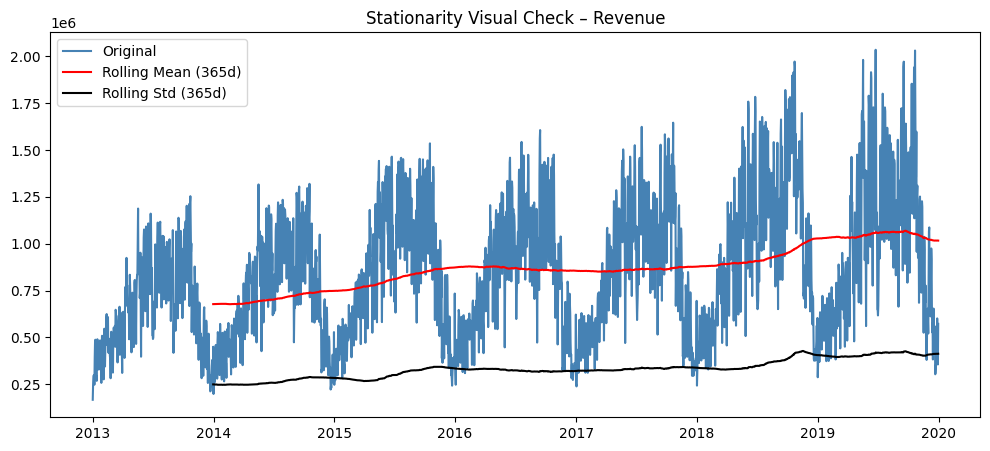

In [25]:
rolling_mean = y.rolling(window=365).mean()
rolling_std = y.rolling(window=365).std()

plt.figure(figsize=(12,5))
plt.plot(y, color='steelblue', label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean (365d)')
plt.plot(rolling_std, color='black', label='Rolling Std (365d)')
plt.legend()
plt.title('Stationarity Visual Check – Revenue')
plt.show()

because our p-value < 0.5, we can reject the $H_0$ and for this reason our timeseries is stationary. Also the test statistic is less than the critical value, confirming the stationarity 

## 7. Autocorrelation Analysis (ACF) and Partial Autocorrelation (PACF)

first we perform the ACF to see the timeseries correlation with itself at different lags

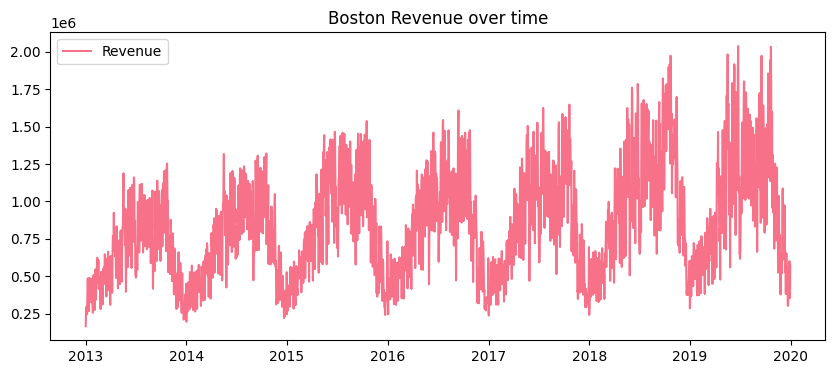

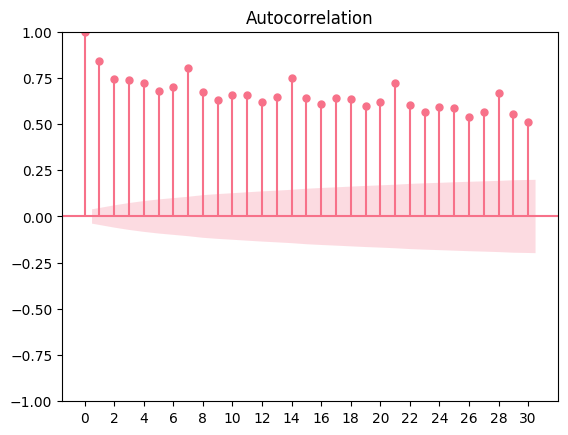

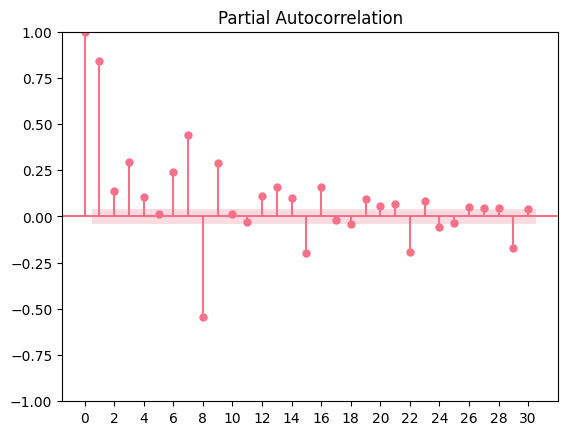

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller



# Plot revenue over time
plt.figure(figsize=(10,4))
plt.plot(df_boston['Revenue'], label="Revenue")
plt.title(f"{CITY} Revenue over time")
plt.legend()
plt.show()

plot_acf(df_boston['Revenue'].dropna(), lags=30)
plt.xticks(ticks=np.arange(0, 31, 2))
plt.show()
plot_pacf(df_boston['Revenue'].dropna(), lags=30)
plt.xticks(ticks=np.arange(0, 31, 2))
plt.show()





- The ACF plot shows clear peaks of autocorrelation every 7 days, indicating strong weekly seasonality in the Revenue data.
- The PACF plot reveals:
  - A moderate positive partial autocorrelation at lag 7 (approximately 0.5).
  - A significant negative partial autocorrelation at lag 8 (approximately -0.5).

These patterns suggest that the time series exhibits weekly cycles, with potential influences from the previous week's values and a negative adjustment at lag 8.

## 8. Outlier Detection

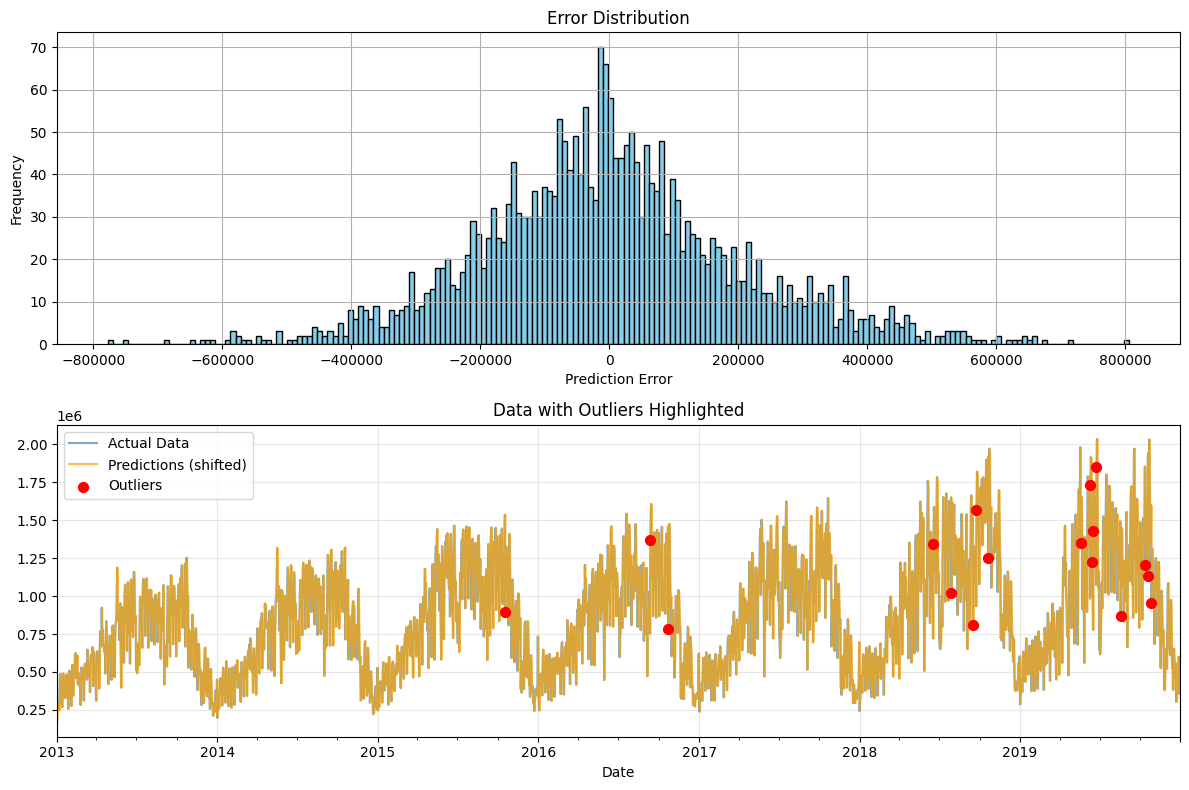

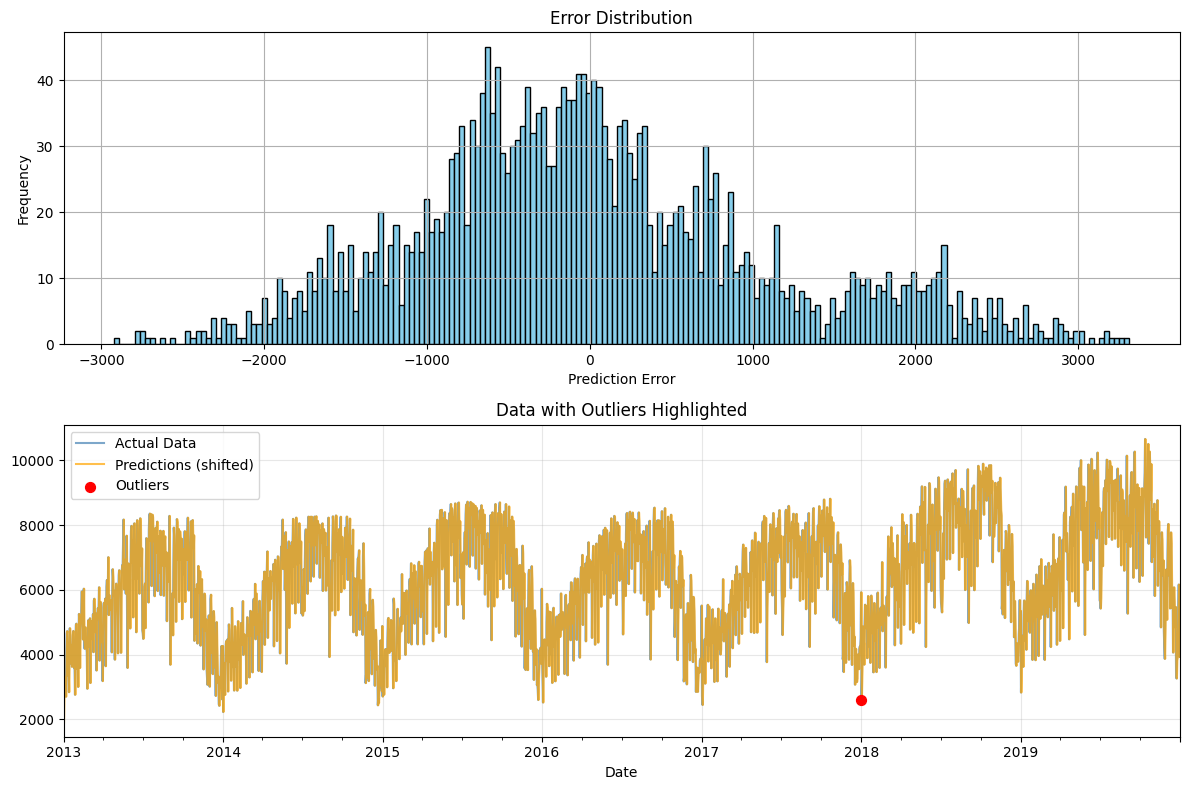

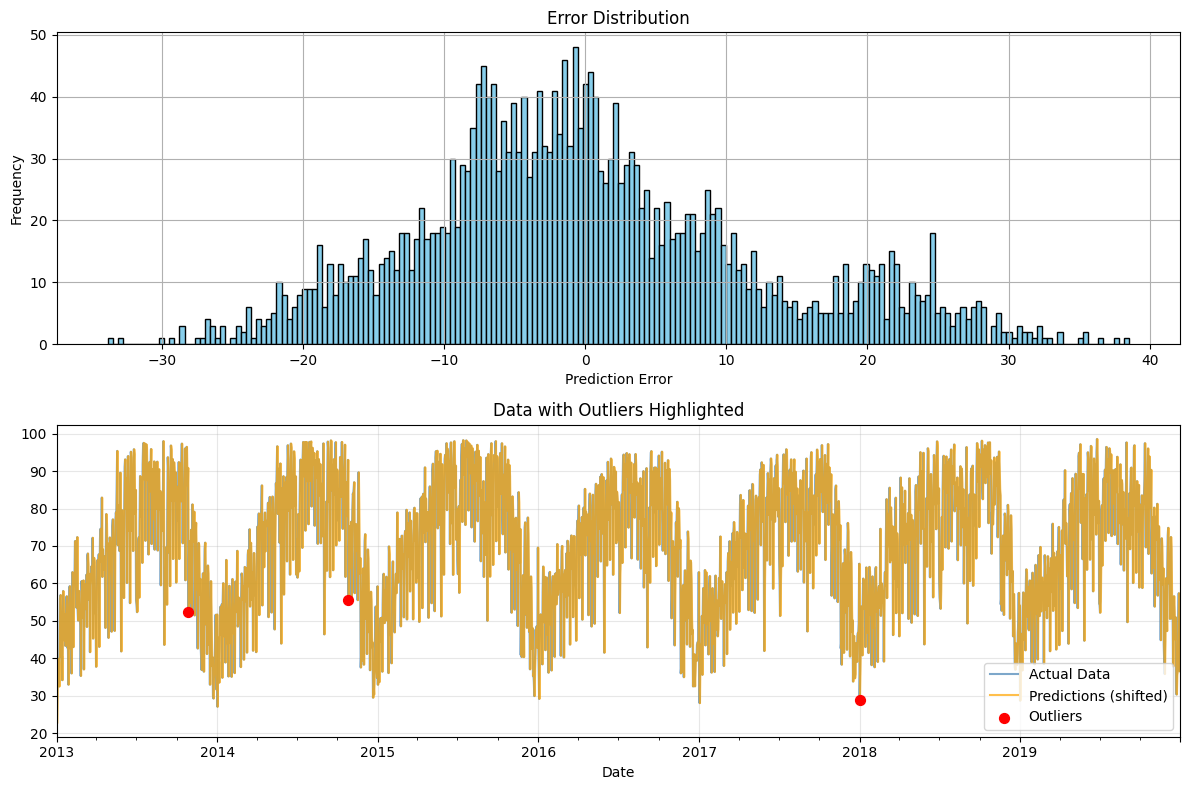

array([ 299,  663, 1826])

In [27]:
def outlier_detector(df, n_sigma=3.):
    preds = df.shift(1)

    # Calculate prediction error and standard deviation
    err = preds - df
    sigma = err.std()
    candidates = np.argwhere((err.abs() > sigma * n_sigma).values).ravel()

    # Filter consecutive outliers to keep only the first
    is_outlier = []
    for i, c in enumerate(candidates):
        if i == 0 or candidates[i - 1] != c - 1:
            is_outlier.append(c)
    is_outlier = np.array(is_outlier)

    # Plot error distribution
    fig, ax = plt.subplots(2, 1, figsize=(12, 8))
    err.hist(bins=200, ax=ax[0], color='skyblue', edgecolor='black')
    ax[0].set_title('Error Distribution')
    ax[0].set_xlabel('Prediction Error')
    ax[0].set_ylabel('Frequency')

    # Plot actual data with outliers highlighted
    df.plot(ax=ax[1], label='Actual Data', alpha=0.7, color='steelblue')
    preds.plot(ax=ax[1], label='Predictions (shifted)', alpha=0.7, color='orange')
    if len(is_outlier) > 0:
        ax[1].scatter(df.index[is_outlier], df.iloc[is_outlier].values, 
                      color='red', label='Outliers', zorder=5, s=50)
    ax[1].set_title('Data with Outliers Highlighted')
    ax[1].legend()
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return is_outlier

# Example usage
outlier_detector(df_boston['Revenue'])
outlier_detector(df_boston['Demand'])
outlier_detector(df_boston['Occupancy'])

Outliers in the Revenue, Demand and Occupancy time series are not many and do not seem to affect the overall trend and seasonality of the data. Therefore, we decide to keep them as they are, as they may represent real-world events that could be important for forecasting.

---

# Adjusting for inflation
In this section we try to adjust the Revenue time series for inflation to ensure that our forecasts reflect real purchasing power over time but also to **mitigate the long-term effects of inflation**. The impact might not be very significant given the relatively short time span of the data (7 years), but it is still a good practice to account for inflation in financial time series analysis.

In [28]:
import pandas as pd
import numpy as np

def adjust_for_inflation(df, revenue_column='Revenue', cpi_series=None, base_year=2013):
    if cpi_series is None:
        raise ValueError("CPI series must be provided. You can obtain CPI data from sources like FRED or BLS.")
    
    # Create a copy of the DataFrame
    df_adjusted = df.copy()
    
    # Get CPI for base year
    base_cpi_value = cpi_series.get(base_year)
    if base_cpi_value is None:
        raise ValueError(f"CPI data for base year {base_year} not found")
    
    # Map yearly CPI values to each date in the DataFrame
    cpi_mapped = df_adjusted.index.year.map(cpi_series)
    
    # Calculate inflation-adjusted revenue
    df_adjusted[f'{revenue_column}_real'] = df_adjusted[revenue_column] * (base_cpi_value / cpi_mapped)
    
    return df_adjusted

In [29]:
import pandas as pd
import numpy as np

cpi_annual = {
    2013: 232.96,
    2014: 236.74,
    2015: 237.02,
    2016: 240.01,
    2017: 245.12,
    2018: 251.11,
    2019: 255.66,
    2020: 258.81
}

# Now apply the inflation adjustment function with the annual CPI
df_boston_adjusted = adjust_for_inflation(df_boston, cpi_series=cpi_annual)

# Display the first few rows of the adjusted DataFrame
print(df_boston_adjusted.head())

           Location        Revenue       Demand  Occupancy Month  Year  \
Date                                                                     
2013-01-01   Boston  166542.843005  1896.791481  22.856617   Jan  2013   
2013-01-02   Boston  245252.313124  2744.958462  33.077154   Jan  2013   
2013-01-03   Boston  289687.425946  3172.063926  38.223838   Jan  2013   
2013-01-04   Boston  297390.047491  3308.052694  39.862523   Jan  2013   
2013-01-05   Boston  291848.455941  3235.525351  38.988557   Jan  2013   

            DayOfWeek   Revenue_real  
Date                                  
2013-01-01    Tuesday  166542.843005  
2013-01-02  Wednesday  245252.313124  
2013-01-03   Thursday  289687.425946  
2013-01-04     Friday  297390.047491  
2013-01-05   Saturday  291848.455941  


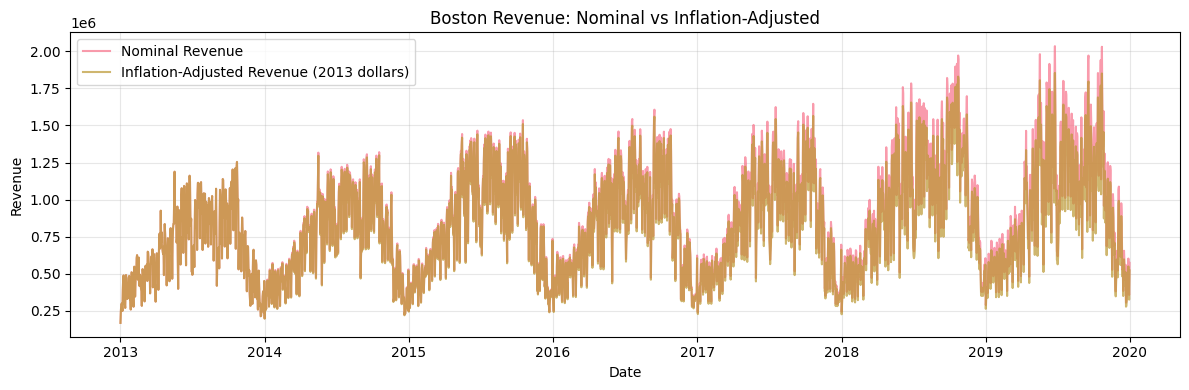


Inflation Impact Summary:
Nominal Revenue Range: $166542.84 - $2035876.60
Inflation-Adjusted Revenue Range: $166542.84 - $1855111.53
Mean Nominal: $868052.99
Mean Inflation-Adjusted: $830894.92


In [30]:

# Plot comparison between nominal and inflation-adjusted revenue
plt.figure(figsize=(12, 4))
plt.plot(df_boston_adjusted['Revenue'], label='Nominal Revenue', alpha=0.7)
plt.plot(df_boston_adjusted['Revenue_real'], label='Inflation-Adjusted Revenue (2013 dollars)', alpha=0.7)
plt.title(f'{CITY} Revenue: Nominal vs Inflation-Adjusted')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Show the difference (inflation impact)
print(f"\nInflation Impact Summary:")
print(f"Nominal Revenue Range: ${df_boston_adjusted['Revenue'].min():.2f} - ${df_boston_adjusted['Revenue'].max():.2f}")
print(f"Inflation-Adjusted Revenue Range: ${df_boston_adjusted['Revenue_real'].min():.2f} - ${df_boston_adjusted['Revenue_real'].max():.2f}")
print(f"Mean Nominal: ${df_boston_adjusted['Revenue'].mean():.2f}")
print(f"Mean Inflation-Adjusted: ${df_boston_adjusted['Revenue_real'].mean():.2f}")


The difference between nominal and real revenue is not very high, indicating that inflation has had a moderate impact on the revenue values over the years. We'll proceed with the non-inflation-adjusted revenue for our forecasting models

# Benchmark Models
The naive, mean and seasonal will be our benchmarks for the development of more complex models.

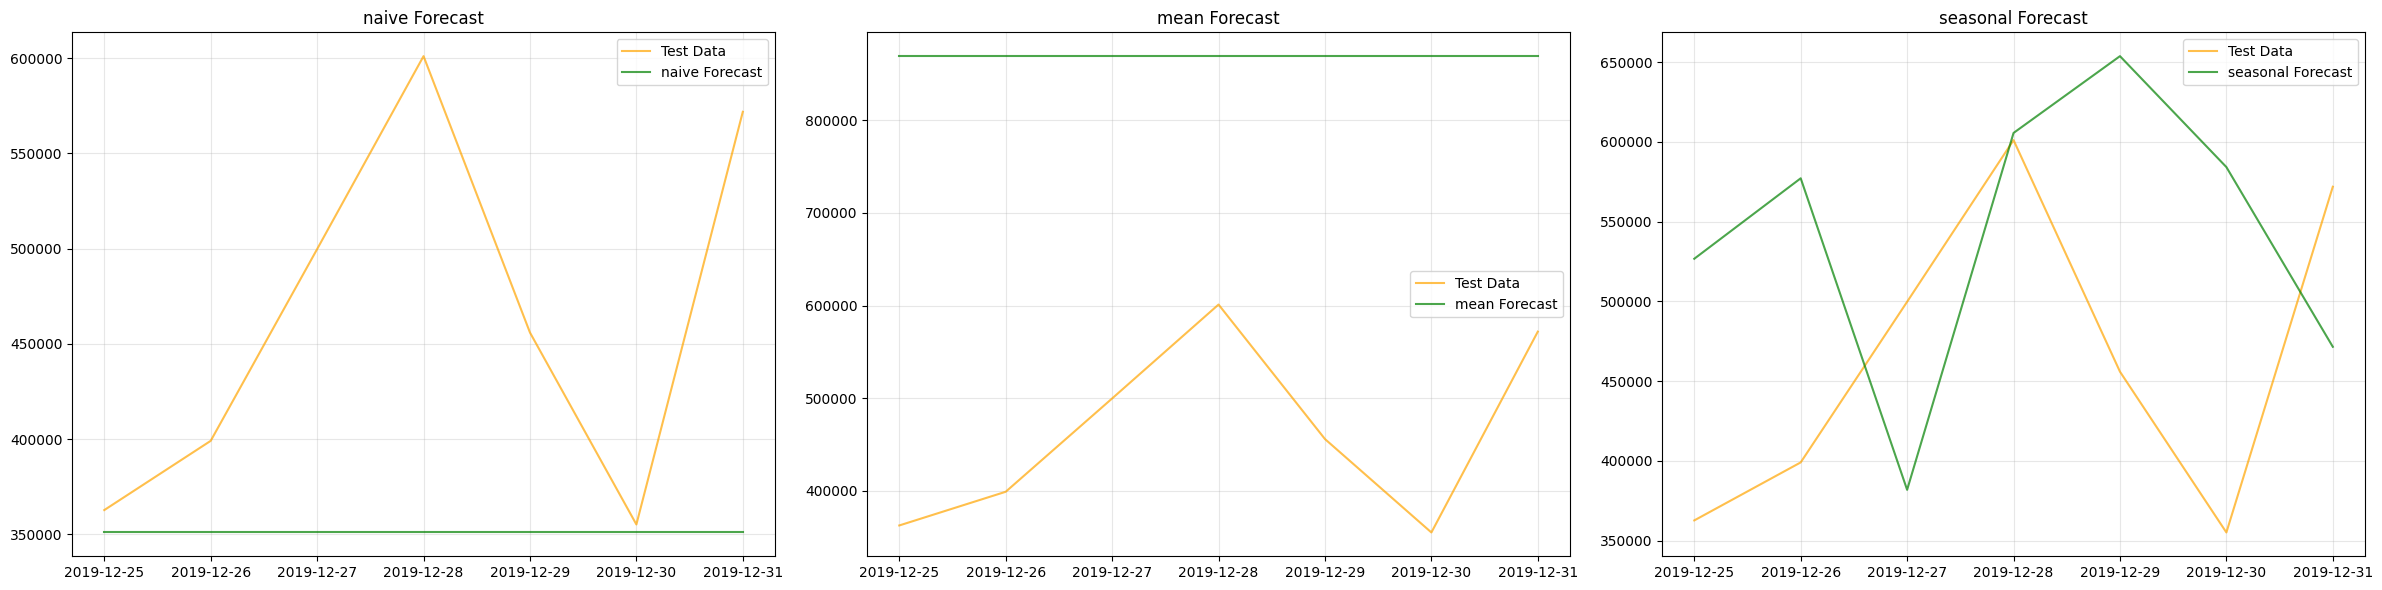

In [45]:
def _as_series(x):
    """Convert input to a numeric pandas Series."""
    if isinstance(x, pd.DataFrame):
        x = x.select_dtypes(include=[np.number])
        if x.shape[1] == 0:
            raise ValueError("No numeric columns in DataFrame.")
        x = x.iloc[:, 0]
    return pd.Series(x).astype(float)

def _cast_series(y, start_idx):
    """Cast forecasted values to a pandas Series with proper indexing."""
    return pd.Series(y, index=np.arange(start_idx, start_idx + len(y)))

def naive(x, h):
    """Naive forecasting: predict the last observed value."""
    xs = _as_series(x)
    y = np.full(h, xs.iloc[-1])
    return _cast_series(y, len(xs))

def mean(x, h):
    """Mean forecasting: predict the mean of the observed values."""
    xs = _as_series(x)
    y = np.full(h, xs.mean())
    return _cast_series(y, len(xs))

def seasonal(x, h, s=12):
    """Seasonal forecasting: repeat the last seasonal period."""
    xs = _as_series(x)
    if len(xs) < s:
        raise ValueError(f"Series length {len(xs)} < seasonal period s={s}.")
    template = xs.iloc[-s:].values
    y = np.resize(template, h)
    return _cast_series(y, len(xs))

def plot_forecasts(df, column_to_forecast='Revenue'):
    """Plot forecasts using naive, mean, and seasonal methods."""
    forecasters = [naive, mean, seasonal]
    forecasters_names = ['naive', 'mean', 'seasonal']
    steps_ahead = 7  # Number of steps to forecast
    fig, ax = plt.subplots(1, len(forecasters), figsize=(24, 6))
    
    # Extract the column to forecast
    series = df[column_to_forecast]
    
    # Split into training and test sets
    df_tr, df_te = series.iloc[:-steps_ahead], series.iloc[-steps_ahead:]
    
    forecasts = {}
    for f, n in zip(forecasters, forecasters_names):
        if n == 'seasonal':
            forecasts[n] = f(df_tr, steps_ahead, s=12)  # Pass seasonal period (s=12)
        else:
            forecasts[n] = f(df_tr, steps_ahead)
    
    for a, (k, v) in zip(ax, forecasts.items()):
        # Use the test set's DatetimeIndex for forecast indices
        forecast_index = df_te.index
        v.index = forecast_index
        
        # Plot only the test data and forecasts
        a.plot(df_te.index, df_te.values, label='Test Data', alpha=0.7, color='orange')
        a.plot(v.index, v.values, label=f'{k} Forecast', alpha=0.7, color='green')
        a.legend()
        a.set_title(f'{k} Forecast')
        a.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Correct usage
plot_forecasts(df_boston_adjusted, column_to_forecast='Revenue')



# Splitting training and test sets

In [46]:
# Ensure the index is a DatetimeIndex
df_boston_adjusted.index = pd.to_datetime(df_boston_adjusted.index)

# Split train and test keeping the dates
df_boston_train = df_boston[df_boston.index < '2019-01-01']
df_boston_test = df_boston[df_boston.index >= '2019-01-01']

# Print the date ranges for train and test sets
print("Train set:", df_boston_train.index.min(), "→", df_boston_train.index.max())
print("Test set:", df_boston_test.index.min(), "→", df_boston_test.index.max())

Train set: 2013-01-01 00:00:00 → 2018-12-31 00:00:00
Test set: 2019-01-01 00:00:00 → 2019-12-31 00:00:00


In [ ]:
df_boston_train.columns

Index(['Location', 'Revenue', 'Demand', 'Occupancy', 'Month', 'Year',
       'DayOfWeek', 'Revenue_real'],
      dtype='object')

## Scaling the data

In [47]:
# scale revenue_real
scaler = StandardScaler()
df_boston_train['Revenue_scaled'] = scaler.fit_transform(df_boston_train[['Revenue']])
df_boston_test['Revenue_scaled'] = scaler.transform(df_boston_test[['Revenue']])

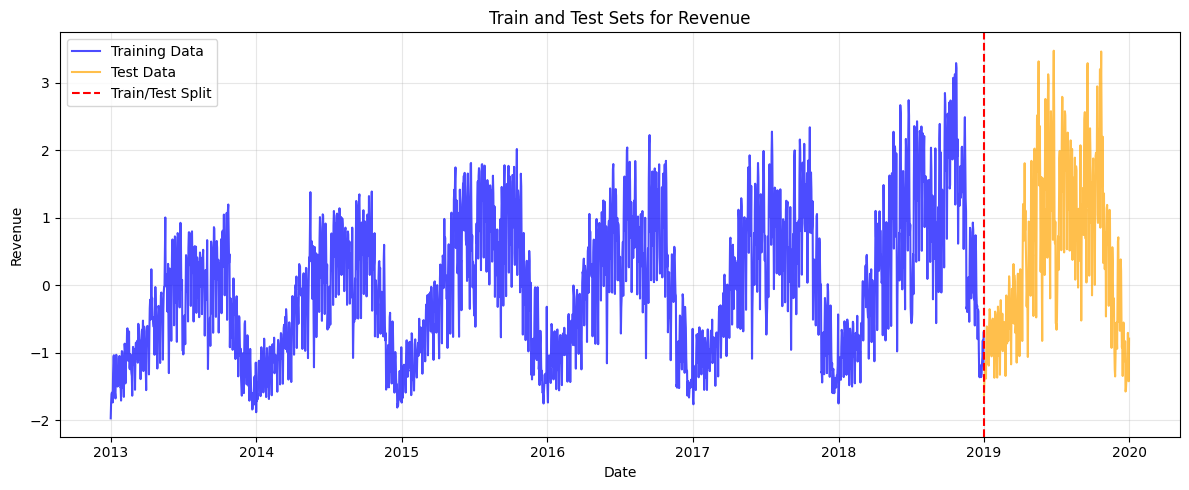

In [48]:
# Plot the train and test sets for all the features
plt.figure(figsize=(12, 5))
plt.plot(df_boston_train.index, df_boston_train['Revenue_scaled'], label='Training Data', alpha=0.7, color='blue')
plt.plot(df_boston_test.index, df_boston_test['Revenue_scaled'], label='Test Data', alpha=0.7, color='orange')
plt.axvline(x=df_boston_train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('Train and Test Sets for Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

                               SARIMAX Results                                
Dep. Variable:         Revenue_scaled   No. Observations:                 2191
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -1563.260
Date:                Mon, 03 Nov 2025   AIC                           3138.520
Time:                        18:20:53   BIC                           3172.670
Sample:                    01-01-2013   HQIC                          3151.002
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3477      0.018    -19.015      0.000      -0.384      -0.312
ar.L2         -0.4215      0.023    -18.241      0.000      -0.467      -0.376
ar.L3         -0.2473      0.025     -9.992      0.0

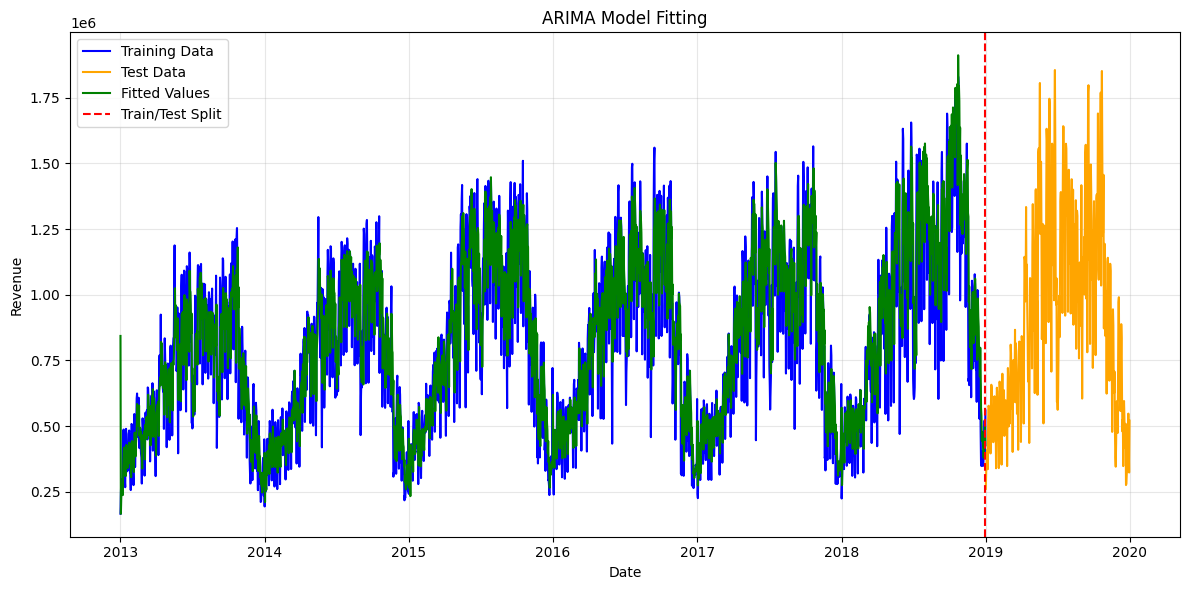

In [ ]:
#apply arima model and make a playable plot to see the results
import statsmodels.api as sm
model = sm.tsa.ARIMA(df_boston_train['Revenue_scaled'], order=(5,1,0))
model_fit = model.fit()
print(model_fit.summary())

# Inverse transform the fitted values to the original scale
fitted_values_original_scale = scaler.inverse_transform(model_fit.fittedvalues.values.reshape(-1, 1))

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(df_boston_train['Revenue_real'], label='Training Data', color='blue')
plt.plot(df_boston_test['Revenue_real'], label='Test Data', color='orange')
plt.plot(df_boston_train.index, fitted_values_original_scale, label='Fitted Values', color='green')  # Corrected
plt.axvline(x=df_boston_train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('ARIMA Model Fitting')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()